# Task 4 — First Machine Learning Classifier

## Decision Tree Classification using Scikit-Learn

This project demonstrates a complete supervised machine learning workflow
using the Iris dataset.

The main steps are:

1. Load and inspect the dataset
2. Prepare features and target
3. Split the data into training and testing sets
4. Train a Decision Tree Classifier
5. Make predictions
6. Evaluate the model using accuracy and a confusion matrix
7. Visualize the results

### Expected Outcome

Understand the basic machine learning pipeline and learn how to evaluate
a classification model using Scikit-Learn.

## 1. Import Required Libraries

We import Pandas for data handling, Matplotlib and Seaborn for
visualization, and Scikit-Learn for machine learning and evaluation.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Iris Dataset

The Iris dataset is a classic classification dataset containing
measurements of iris flowers.

The model will predict the flower species using four features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In [137]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

df = X.copy()
df["target"] = y
df["species"] = y.map(
    dict(enumerate(iris.target_names))
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Explore the Dataset

Before training the model, we inspect the structure and basic
statistics of the dataset.

In [138]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (150, 6)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [139]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0



Duplicate rows: 1


## 4. Prepare Features and Target

The feature matrix `X` contains the flower measurements.

The target variable `y` contains the species labels:

- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

In [140]:
X = df[iris.feature_names]
y = df["target"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,target
0,0
1,0
2,0
3,0
4,0


## 5. Split the Dataset into Training and Testing Sets

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to learn patterns, while the testing data
is used to evaluate how well the model performs on unseen data.

`random_state=42` makes the split reproducible.

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 6. Train the Decision Tree Classifier

A Decision Tree learns a series of decision rules from the training
data and uses those rules to classify new observations.

We limit the tree depth to reduce unnecessary complexity and make
the model easier to understand.

In [142]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 7. Make Predictions

The trained model is now used to predict the species of flowers
in the unseen testing dataset.

In [143]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


## 8. Model Accuracy

Accuracy measures the percentage of test samples that were classified
correctly.

A higher accuracy means that more test observations were predicted
correctly.

In [144]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.9667
Model Accuracy: 96.67%


## 9. Confusion Matrix

A confusion matrix shows the number of correct and incorrect
predictions for each class.

The rows represent the actual classes, while the columns represent
the predicted classes.

In [145]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 10. Visualize the Confusion Matrix

A heatmap makes the confusion matrix easier to interpret.

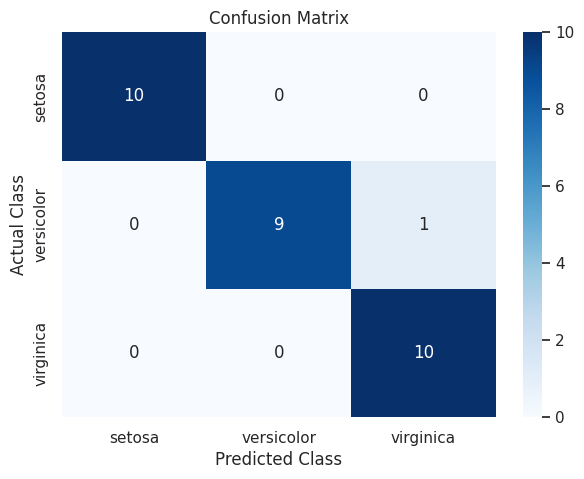

In [146]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## 11. Classification Report

The classification report provides additional evaluation metrics:

- Precision
- Recall
- F1-score
- Support

These metrics provide more detailed information than accuracy alone.

In [147]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 12. Visualize the Decision Tree

The trained Decision Tree can be visualized to understand the
decision rules used by the model.

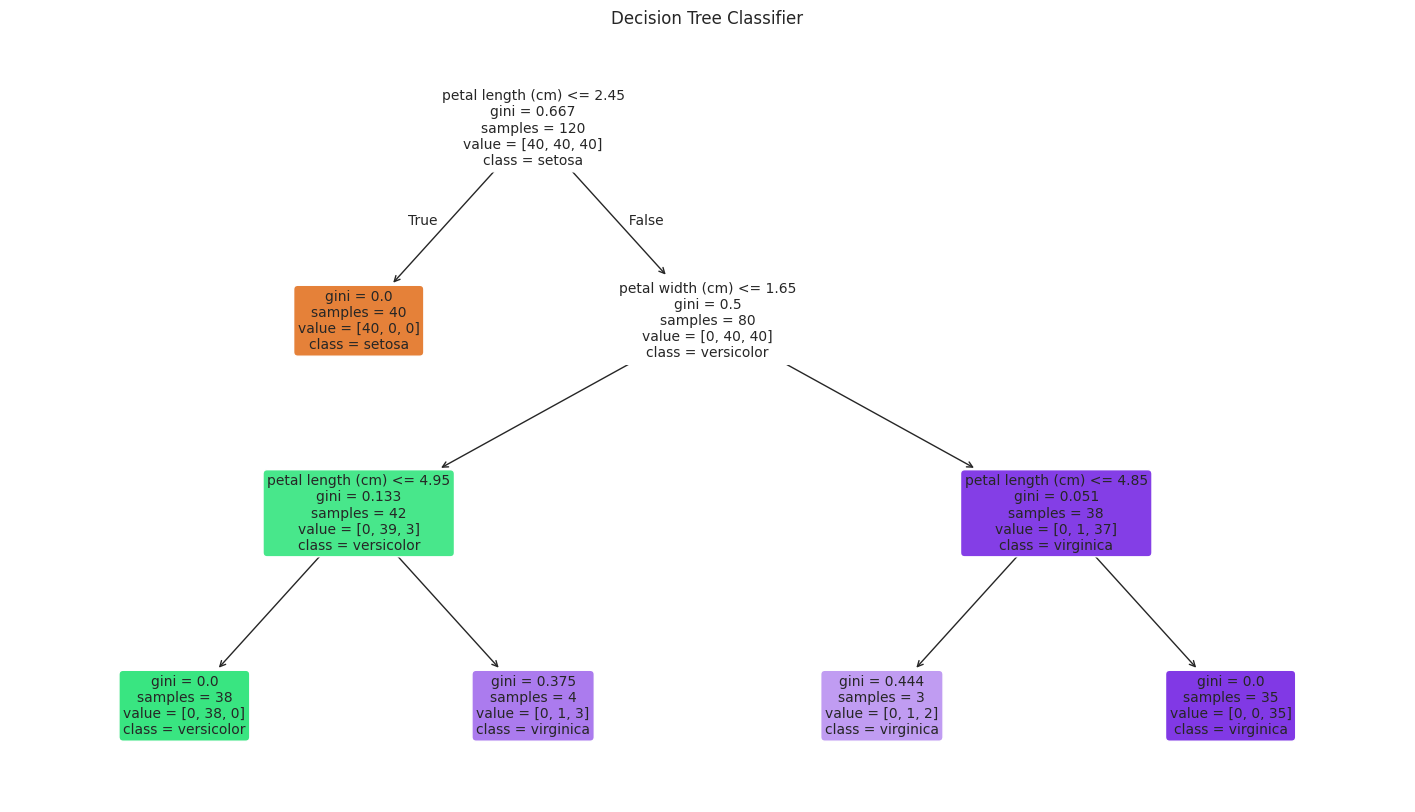

In [148]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier")
plt.show()

## 13. Feature Importance

Decision Trees can estimate how important each feature was when
making classification decisions.

A larger importance value indicates that the feature contributed
more to the model's decisions.

In [149]:
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,petal length (cm),0.579077
3,petal width (cm),0.420923
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


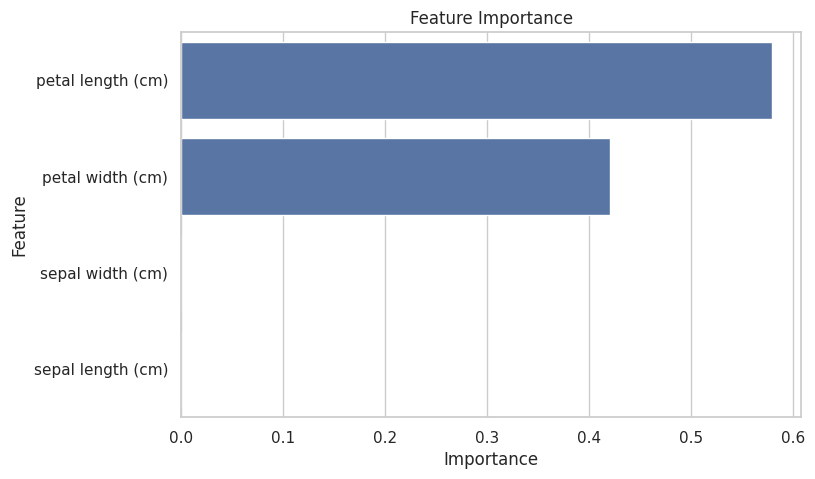

In [150]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 14. Compare Actual and Predicted Classes

We create a small table to compare the actual flower species
with the predictions generated by the model.

In [151]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Actual Species"] = comparison["Actual"].map(
    dict(enumerate(iris.target_names))
)

comparison["Predicted Species"] = comparison["Predicted"].map(
    dict(enumerate(iris.target_names))
)

display(comparison)

,Actual,Predicted,Actual Species,Predicted Species
0,0,0,setosa,setosa
1,2,2,virginica,virginica
2,1,1,versicolor,versicolor
3,1,1,versicolor,versicolor
4,0,0,setosa,setosa
5,1,1,versicolor,versicolor
6,0,0,setosa,setosa
7,0,0,setosa,setosa
8,2,2,virginica,virginica
9,1,1,versicolor,versicolor


## 15. Final Model Evaluation

The Decision Tree successfully learned to classify Iris flowers
from their physical measurements.

The model was evaluated using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

The confusion matrix helps identify which classes were correctly
or incorrectly classified.

In [152]:
print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

FINAL MODEL EVALUATION
Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Conclusion

In this project, a Decision Tree Classifier was developed using
Scikit-Learn and the Iris dataset.

### Key Concepts Learned

- Preparing features and target variables
- Splitting data into training and testing sets
- Training a machine learning model
- Making predictions on unseen data
- Measuring model accuracy
- Understanding confusion matrices
- Using precision, recall and F1-score
- Visualizing a Decision Tree
- Understanding feature importance

### Machine Learning Pipeline

The complete workflow followed was:

**Data → Features & Target → Train/Test Split → Model Training → Prediction → Evaluation**

This project provides a foundation for building more advanced
supervised machine learning models.